# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [8]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

<Axes: title={'center': 'Distribution of Mode'}>

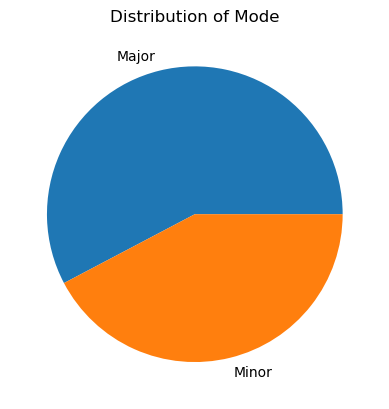

In [9]:
df['mode'].value_counts().plot(kind='pie', title='Distribution of Mode', ylabel='')

<Axes: title={'center': 'Distribution of Key'}, xlabel='Key', ylabel='Count'>

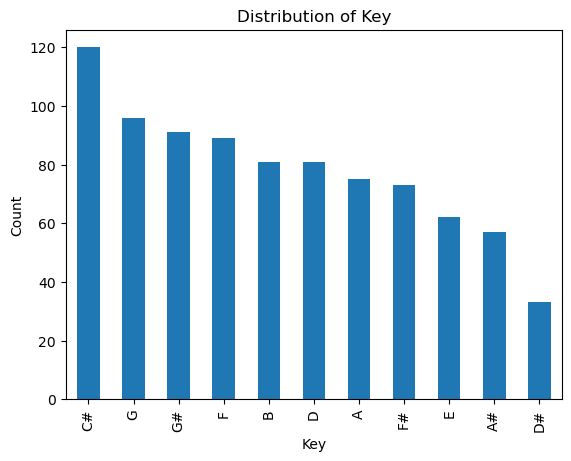

In [10]:
df['key'].value_counts().plot(kind='bar', title='Distribution of Key', xlabel='Key', ylabel='Count')

quant_features = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
df[quant_features].hist(figsize=(10, 8), bins=20)

In [12]:
quant_features = ['bpm', 'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']
df[quant_features].describe()

,bpm,danceability_%,energy_%,speechiness_%,acousticness_%
count,953.000000,953.00000,953.000000,953.000000,953.000000
mean,122.540399,66.96957,64.279119,10.131165,27.057712
std,28.057802,14.63061,16.550526,9.912888,25.996077
min,65.000000,23.00000,9.000000,2.000000,0.000000
25%,100.000000,57.00000,53.000000,4.000000,6.000000
50%,121.000000,69.00000,66.000000,6.000000,18.000000
75%,140.000000,78.00000,77.000000,11.000000,43.000000
max,206.000000,96.00000,97.000000,64.000000,97.000000


In [13]:
hit_songs = df[
    (df['key'] == 'C#') & (df['mode'] == 'Major') &
    (df['bpm'] >= 100) & (df['bpm'] <= 140) &
    (df['danceability_%'] >= 57) & (df['danceability_%'] <= 78) &
    (df['energy_%'] >= 53) & (df['energy_%'] <= 77) &
    (df['speechiness_%'] >= 4) & (df['speechiness_%'] <= 11) &
    (df['acousticness_%'] >= 6) & (df['acousticness_%'] <= 43)
]
print("--- Formula Matches ---")
display(hit_songs[['track_name', 'artist(s)_name', 'streams']])
print("\n--- Blinding Lights Stats ---")
display(df[df['track_name'] == 'Blinding Lights'][['track_name', 'bpm', 'key', 'mode', 'danceability_%', 'energy_%']])

--- Formula Matches ---


,track_name,artist(s)_name,streams
518,Need To Know,Doja Cat,1042568408
660,Ginseng Strip 2002,Yung Lean,240769997



--- Blinding Lights Stats ---


,track_name,bpm,key,mode,danceability_%,energy_%
55,Blinding Lights,171,C#,Major,50,80
